# Demand Forecasting for AeroNet Lite
## BSDS Semester Project SP2026

This notebook trains regression models to predict delivery demand using the Bike Sharing Dataset.
The trained model will be saved and used by ml_pipeline.py for real-time demand forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load Dataset

In [2]:
data_path = "../extracted_data/bike_sharing/train.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Dataset loaded from {data_path}")
    print(f"Shape: {df.shape}")
else:
    print(f"File not found at {data_path}")
    df = None

Dataset loaded from ../extracted_data/bike_sharing/train.csv
Shape: (10886, 12)


In [3]:
print("First 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  

Column names:
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

Data types:
datetime       object
season          int64

In [4]:
print("Statistical summary:")
print(df.describe())

Statistical summary:
             season       holiday    workingday       weather         temp  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.00000   
mean       2.506614      0.028569      0.680875      1.418427     20.23086   
std        1.116174      0.166599      0.466159      0.633839      7.79159   
min        1.000000      0.000000      0.000000      1.000000      0.82000   
25%        2.000000      0.000000      0.000000      1.000000     13.94000   
50%        3.000000      0.000000      1.000000      1.000000     20.50000   
75%        4.000000      0.000000      1.000000      2.000000     26.24000   
max        4.000000      1.000000      1.000000      4.000000     41.00000   

              atemp      humidity     windspeed        casual    registered  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.000000   
mean      23.655084     61.886460     12.799395     36.021955    155.552177   
std        8.474601     19.245033      

## 2. Feature Engineering

In [5]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['day_of_year'] = df['datetime'].dt.dayofyear

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['is_rush_hour'] = ((df['hour'] >= 7) & (df['hour'] <= 9) | 
                      (df['hour'] >= 17) & (df['hour'] <= 19)).astype(int)

print("Feature engineering completed")
print(f"Total columns: {len(df.columns)}")

Feature engineering completed
Total columns: 20


## 3. Exploratory Data Analysis

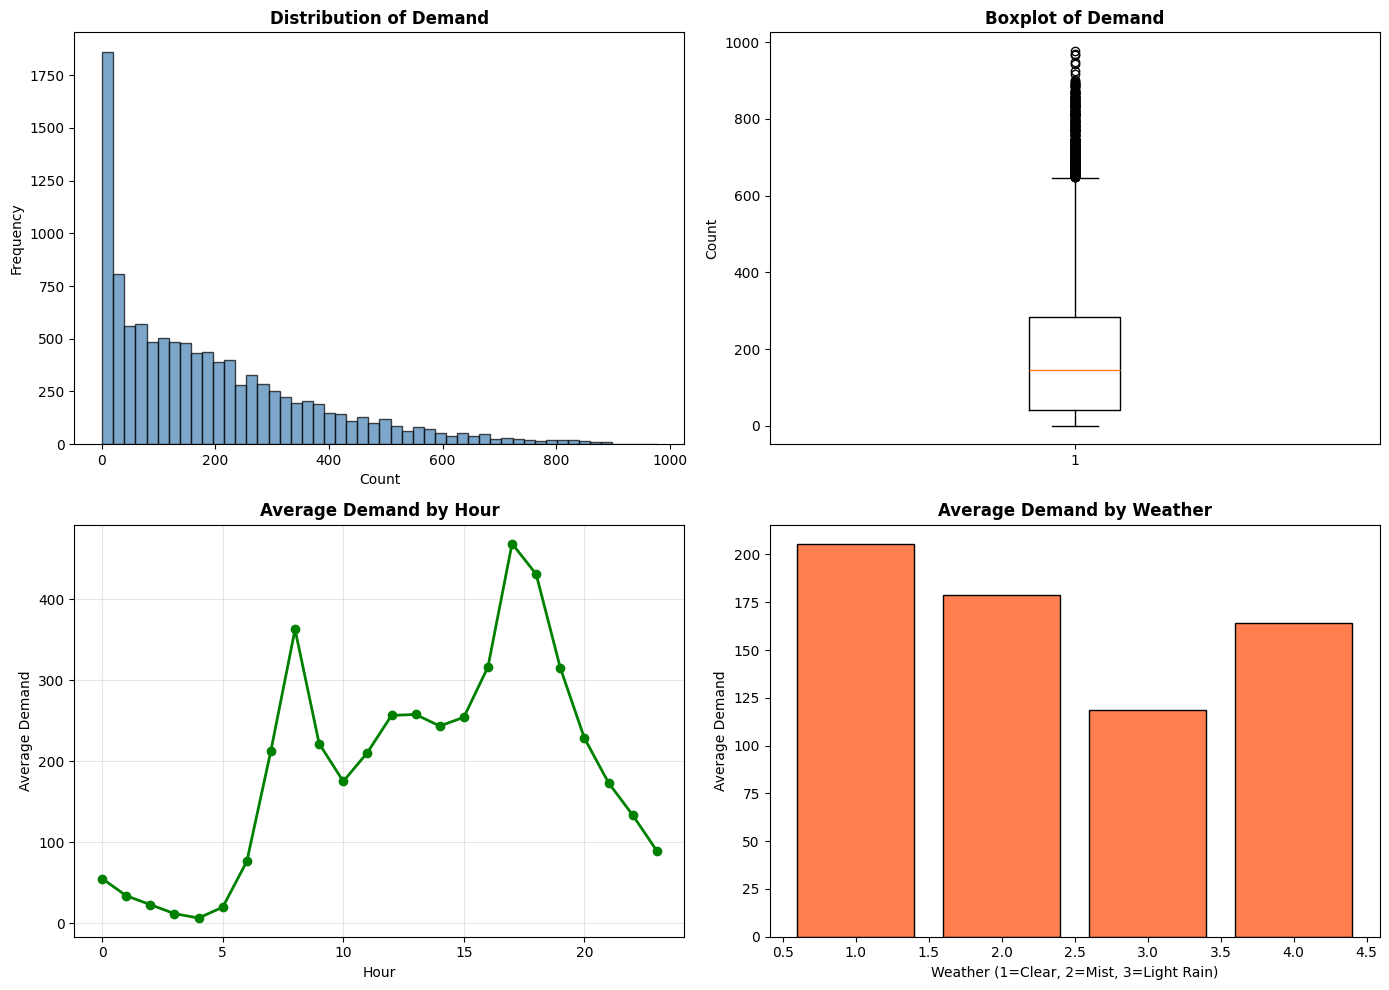

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Demand', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].boxplot(df['count'])
axes[0, 1].set_title('Boxplot of Demand', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')

hour_demand = df.groupby('hour')['count'].mean()
axes[1, 0].plot(hour_demand.index, hour_demand.values, marker='o', linewidth=2, color='green')
axes[1, 0].set_title('Average Demand by Hour', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Average Demand')
axes[1, 0].grid(True, alpha=0.3)

weather_demand = df.groupby('weather')['count'].mean()
axes[1, 1].bar(weather_demand.index, weather_demand.values, color='coral', edgecolor='black')
axes[1, 1].set_title('Average Demand by Weather', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Weather (1=Clear, 2=Mist, 3=Light Rain)')
axes[1, 1].set_ylabel('Average Demand')

plt.tight_layout()
plt.show()

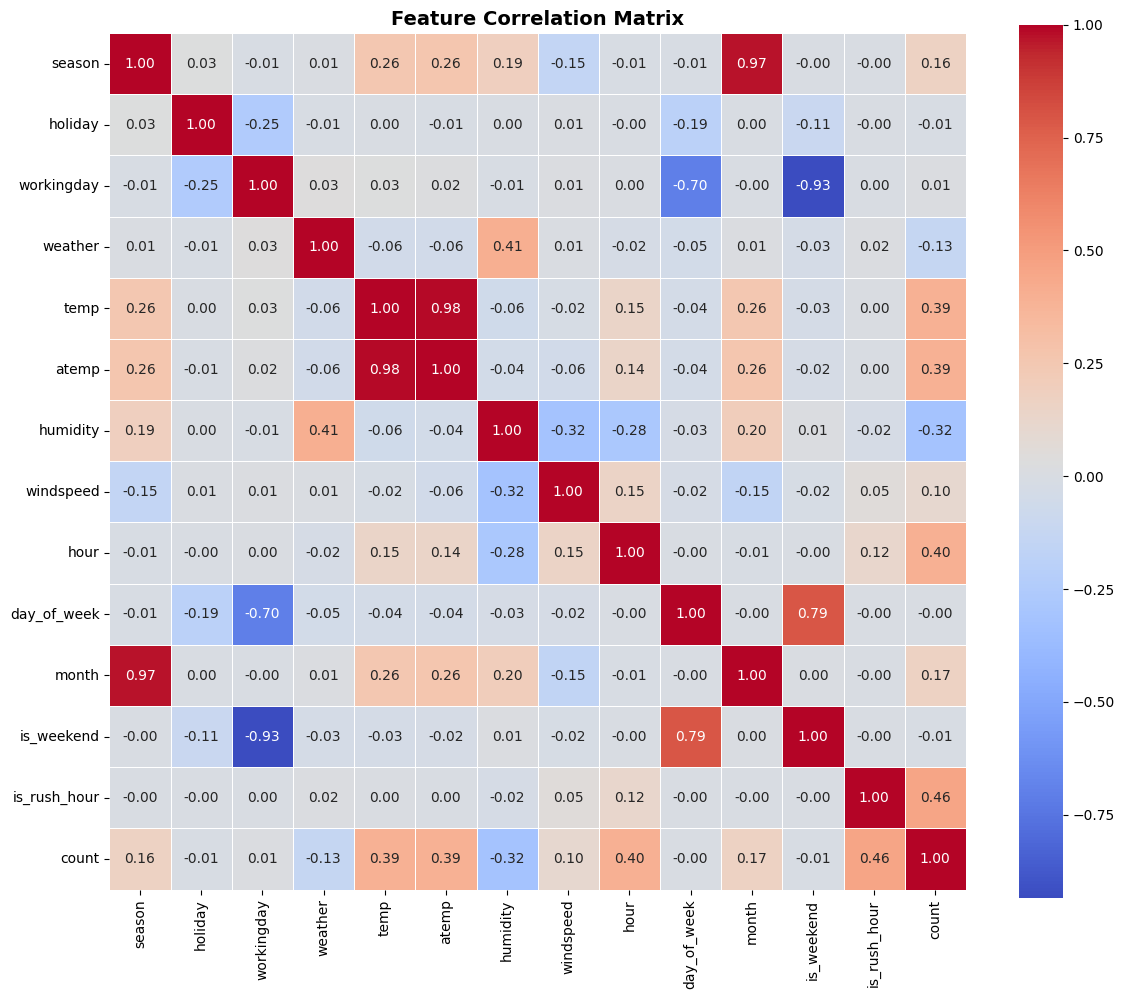

Top 5 features correlated with demand:
is_rush_hour    0.460054
hour            0.400601
temp            0.394454
atemp           0.389784
month           0.166862
Name: count, dtype: float64


In [7]:
numeric_cols = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 
                'humidity', 'windspeed', 'hour', 'day_of_week', 'month', 
                'is_weekend', 'is_rush_hour', 'count']

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 features correlated with demand:")
corr_with_target = correlation_matrix['count'].sort_values(ascending=False)
print(corr_with_target[1:6])

## 4. Prepare Features for Modeling

In [8]:
feature_columns = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 
                   'humidity', 'windspeed', 'hour', 'month', 'day_of_week', 
                   'is_weekend', 'is_rush_hour']

X = df[feature_columns].copy()
y = df['count'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:\n{feature_columns}")

Features shape: (10886, 13)
Target shape: (10886,)

Feature columns:
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'month', 'day_of_week', 'is_weekend', 'is_rush_hour']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")
print("Features scaled successfully")

Training set size: 8708
Test set size: 2178
Features scaled successfully


## 5. Train and Compare Models

In [10]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    }
    
    print(f"  MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")
    print("-" * 40)

Training Linear Regression...
  MAE: 95.63, RMSE: 128.29, R2: 0.5014
----------------------------------------
Training Ridge Regression...
  MAE: 95.63, RMSE: 128.29, R2: 0.5014
----------------------------------------
Training Lasso Regression...
  MAE: 95.63, RMSE: 128.29, R2: 0.5014
----------------------------------------
Training Random Forest...
  MAE: 44.06, RMSE: 65.78, R2: 0.8689
----------------------------------------
Training Gradient Boosting...
  MAE: 46.13, RMSE: 66.34, R2: 0.8667
----------------------------------------


## 6. Model Performance Comparison

MODEL PERFORMANCE COMPARISON
            Model       MAE       RMSE  R2 Score
    Random Forest 44.063392  65.783816  0.868891
Gradient Boosting 46.126307  66.338193  0.866672
 Ridge Regression 95.626931 128.289587  0.501371
 Lasso Regression 95.627841 128.289959  0.501368
Linear Regression 95.628100 128.290032  0.501367


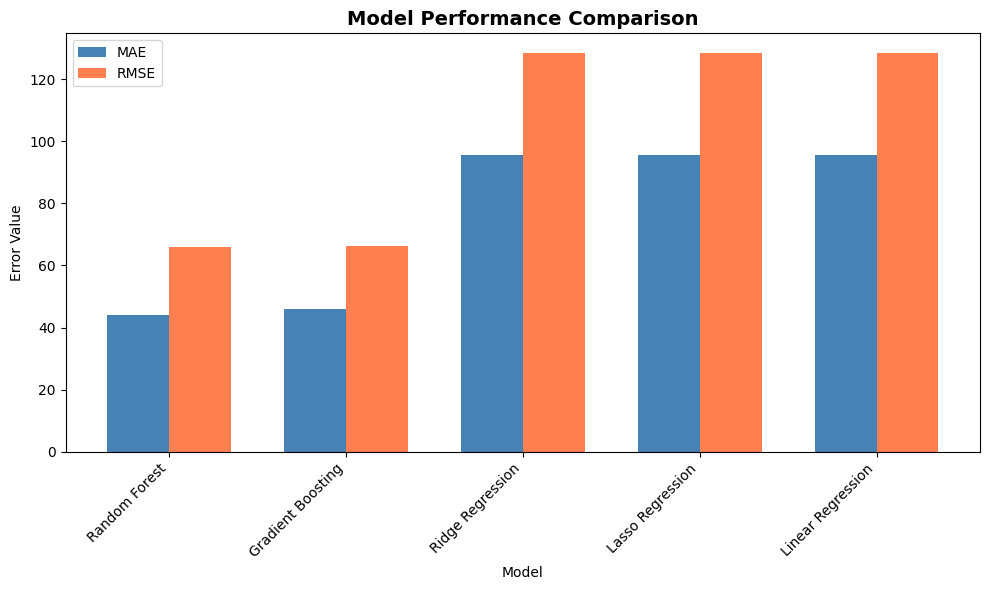

In [11]:
print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['mae'] for m in results],
    'RMSE': [results[m]['rmse'] for m in results],
    'R2 Score': [results[m]['r2'] for m in results]
})

comparison_df = comparison_df.sort_values('R2 Score', ascending=False)
print(comparison_df.to_string(index=False))

plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.35

plt.bar(x - width/2, comparison_df['MAE'], width, label='MAE', color='steelblue')
plt.bar(x + width/2, comparison_df['RMSE'], width, label='RMSE', color='coral')

plt.xlabel('Model')
plt.ylabel('Error Value')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Select Best Model

Best Model: Random Forest
R2 Score: 0.8689


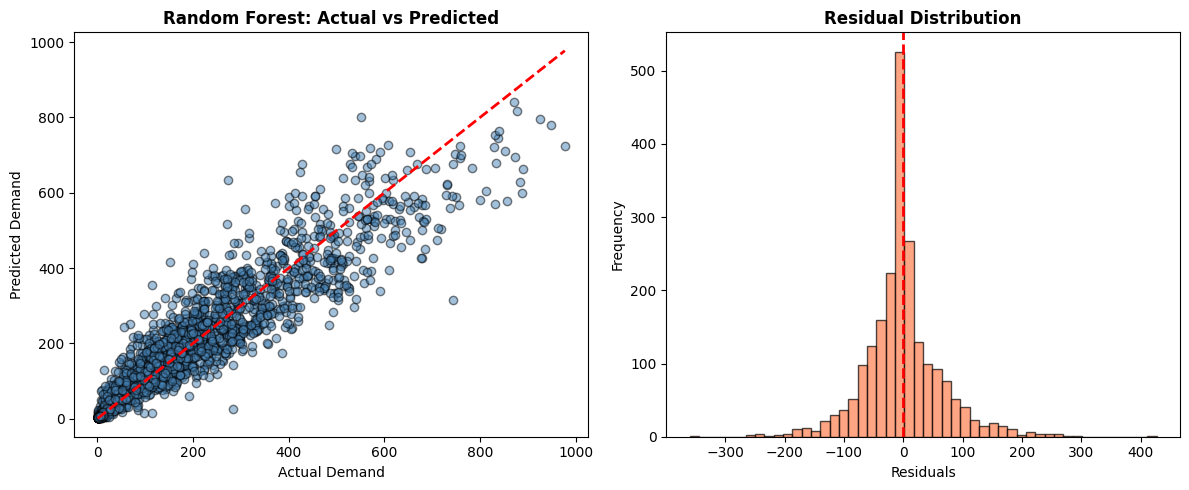

In [12]:
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_r2 = comparison_df.iloc[0]['R2 Score']

print(f"Best Model: {best_model_name}")
print(f"R2 Score: {best_r2:.4f}")

y_pred_best = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', edgecolor='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Demand')
axes[0].set_ylabel('Predicted Demand')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted', fontsize=12, fontweight='bold')

residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

In [13]:
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-validation R2 scores: {cv_scores}")
print(f"Mean CV R2: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-validation R2 scores: [0.85967306 0.86254446 0.86456187 0.87303595 0.85517457]
Mean CV R2: 0.8630 (+/- 0.0119)


## 8. Feature Importance

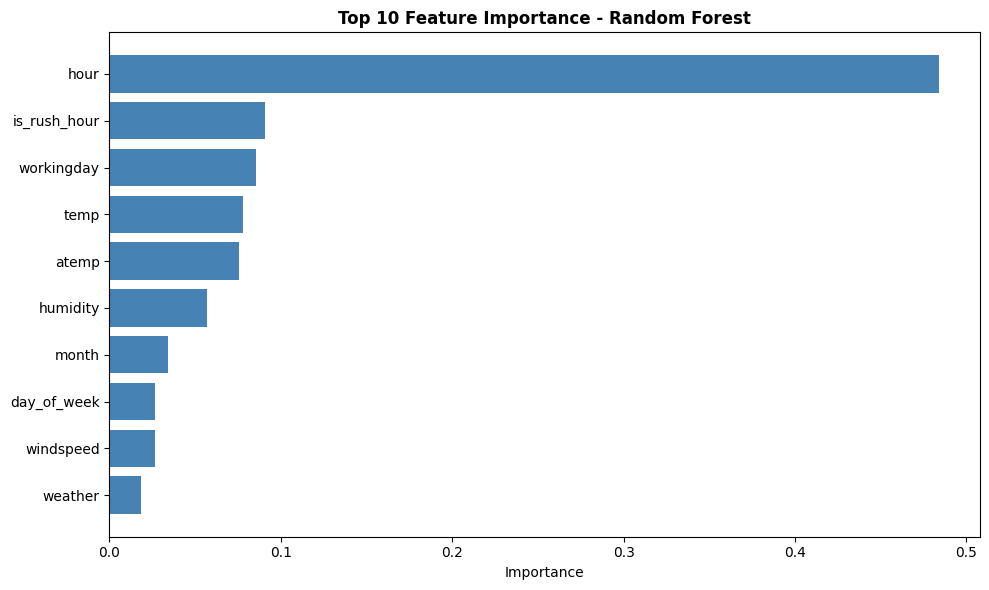

         Feature  Importance
8           hour    0.483725
12  is_rush_hour    0.090492
2     workingday    0.085430
4           temp    0.077986
5          atemp    0.075820
6       humidity    0.056617
9          month    0.034316
10   day_of_week    0.026749
7      windspeed    0.026301
3        weather    0.018287


In [14]:
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10], color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Top 10 Feature Importance - {best_model_name}', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(feature_importance.head(10))

## 9. Hyperparameter Tuning

In [15]:
if best_model_name == 'Random Forest':
    print("Performing hyperparameter tuning for Random Forest...")
    
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5, 10]
    }
    
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV R2 score: {grid_search.best_score_:.4f}")
    
    tuned_model = grid_search.best_estimator_
    y_pred_tuned = tuned_model.predict(X_test_scaled)
    tuned_r2 = r2_score(y_test, y_pred_tuned)
    
    print(f"Tuned model R2 on test set: {tuned_r2:.4f}")
    
    if tuned_r2 > best_r2:
        print("Tuned model performs better. Using tuned model.")
        best_model = tuned_model
        best_r2 = tuned_r2

Performing hyperparameter tuning for Random Forest...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}
Best CV R2 score: 0.8587
Tuned model R2 on test set: 0.8709
Tuned model performs better. Using tuned model.


## 10. Save Model for Production

In [16]:
model_dir = "../data/processed/"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "demand_model.pkl")
scaler_path = os.path.join(model_dir, "demand_scaler.pkl")
features_path = os.path.join(model_dir, "demand_features.pkl")

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(feature_columns, features_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")
print(f"Features saved to: {features_path}")

print("\n" + "="*50)
print("DEMAND FORECASTING MODEL READY")
print("="*50)
print(f"Best Model: {best_model_name}")
print(f"Final R2 Score: {best_r2:.4f}")
print("\nThis model will be used by ml_pipeline.py")

Model saved to: ../data/processed/demand_model.pkl
Scaler saved to: ../data/processed/demand_scaler.pkl
Features saved to: ../data/processed/demand_features.pkl

DEMAND FORECASTING MODEL READY
Best Model: Random Forest
Final R2 Score: 0.8709

This model will be used by ml_pipeline.py


## 11. Test Prediction Function

In [17]:
print("Testing prediction function...")

def predict_demand(hour, temperature, humidity, weather=1, is_holiday=0, is_weekend=0):
    test_features = pd.DataFrame([[
        2, is_holiday, 1, weather, temperature, temperature, 
        humidity, 10, hour, 6, 2, is_weekend, 1 if (7 <= hour <= 9 or 17 <= hour <= 19) else 0
    ]], columns=feature_columns)
    
    test_scaled = scaler.transform(test_features)
    prediction = best_model.predict(test_scaled)[0]
    return max(0, prediction)

print("\nSample predictions:")
print(f"Hour 8, Temp 20C, Humidity 60%: {predict_demand(8, 20, 60):.0f}")
print(f"Hour 12, Temp 25C, Humidity 50%: {predict_demand(12, 25, 50):.0f}")
print(f"Hour 18, Temp 15C, Humidity 80%: {predict_demand(18, 15, 80):.0f}")
print(f"Hour 22, Temp 10C, Humidity 90%: {predict_demand(22, 10, 90):.0f}")

print("\n" + "="*50)
print("NOTEBOOK EXECUTION COMPLETE")
print("="*50)

Testing prediction function...

Sample predictions:
Hour 8, Temp 20C, Humidity 60%: 573
Hour 12, Temp 25C, Humidity 50%: 251
Hour 18, Temp 15C, Humidity 80%: 360
Hour 22, Temp 10C, Humidity 90%: 68

NOTEBOOK EXECUTION COMPLETE
